2026-08-12 17:38:25.978 | INFO     | __main__:node_a:12 - cur_step: 1, node_a 被触发
2026-08-12 17:38:25.979 | INFO     | __main__:node_b:17 - cur_step: 2, node_b 被触发
2026-08-12 17:38:25.980 | INFO     | __main__:node_c:22 - cur_step: 2, node_c 被触发
2026-08-12 17:38:25.981 | INFO     | __main__:node_d:27 - cur_step: 3, node_d 被触发
2026-08-12 17:38:25.981 | INFO     | __main__:node_e:32 - cur_step: 3, node_e 被触发
2026-08-12 17:38:25.982 | INFO     | __main__:node_e:32 - cur_step: 4, node_e 被触发


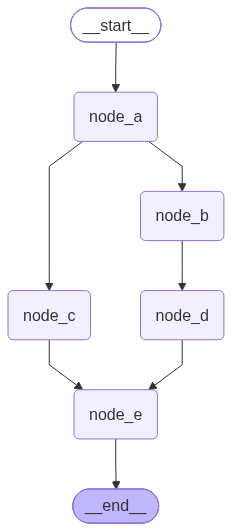

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	node_a(node_a)
	node_b(node_b)
	node_c(node_c)
	node_d(node_d)
	node_e(node_e)
	__end__([<p>__end__</p>]):::last
	__start__ --> node_a;
	node_a --> node_b;
	node_a --> node_c;
	node_b --> node_d;
	node_c --> node_e;
	node_d --> node_e;
	node_e --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



In [5]:
from typing import TypedDict
from loguru import logger
from langchain_core.runnables import RunnableConfig
from langgraph.graph import StateGraph, START, END

#1. 定义状态
class EmptyState(TypedDict):
    pass
#2. 声明节点
def node_a(state:EmptyState,config:RunnableConfig) -> EmptyState:
    cur_step = config["metadata"]["langgraph_step"]
    logger.info("cur_step: {}, node_a 被触发", cur_step)    
    return {}

def node_b(state:EmptyState,config:RunnableConfig) -> EmptyState:
    cur_step = config["metadata"]["langgraph_step"]
    logger.info("cur_step: {}, node_b 被触发", cur_step)    
    return {}

def node_c(state:EmptyState,config:RunnableConfig) -> EmptyState:
    cur_step = config["metadata"]["langgraph_step"]
    logger.info("cur_step: {}, node_c 被触发", cur_step)
    return {}

def node_d(state:EmptyState,config:RunnableConfig) -> EmptyState:
    cur_step = config["metadata"]["langgraph_step"]
    logger.info("cur_step: {}, node_d 被触发", cur_step)
    return {}

def node_e(state:EmptyState,config:RunnableConfig) -> EmptyState:
    cur_step = config["metadata"]["langgraph_step"]
    logger.info("cur_step: {}, node_e 被触发", cur_step)
    return {}

#3. 构建图
builder = StateGraph(state_schema=EmptyState)
builder.add_node("node_a",node_a)
builder.add_node("node_b",node_b)
builder.add_node("node_c",node_c)
builder.add_node("node_d",node_d)
builder.add_node("node_e",node_e)

builder.add_edge(START,"node_a")
builder.add_edge("node_a","node_b")
builder.add_edge("node_a","node_c")
builder.add_edge("node_b","node_d")
# 或节点扇入关系
builder.add_edge("node_c","node_e")
builder.add_edge("node_d","node_e")
# 与节点扇入关系
# builder.add_edge(["node_c","node_d"],"node_e") # c d 都要执行完，才会到e

builder.add_edge("node_e",END)

graph = builder.compile()
graph.invoke({})

from IPython.display import display
display(graph)

raw_mermaid = graph.get_graph().draw_mermaid()
print(raw_mermaid)